In [1]:
##TASK 1
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

print(df.shape)
df.head()

(299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
X = df.drop("DEATH_EVENT", axis=1)
y = df["DEATH_EVENT"]

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(209, 12) (45, 12) (45, 12)


In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

### MODEL 1 LOGISTIC REGRESSION

In [6]:
log_reg = LogisticRegression(max_iter=1000)

log_reg.fit(X_train, y_train)

val_pred = log_reg.predict(X_val)
test_pred = log_reg.predict(X_test)

val_auc = roc_auc_score(y_val, log_reg.predict_proba(X_val)[:,1])
test_auc = roc_auc_score(y_test, log_reg.predict_proba(X_test)[:,1])

print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Test Accuracy:", accuracy_score(y_test, test_pred))

print("Validation ROC-AUC:", val_auc)
print("Test ROC-AUC:", test_auc)

Validation Accuracy: 0.8444444444444444
Test Accuracy: 0.8222222222222222
Validation ROC-AUC: 0.9177777777777778
Test ROC-AUC: 0.8064516129032259


### MODEL 2 MLP

In [9]:
model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
from sklearn.neural_network import MLPClassifier

# Create MLP model
mlp = MLPClassifier(
    hidden_layer_sizes=(16,),
    activation='relu',
    max_iter=500,
    random_state=42
)

# Train the model
mlp.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=42)

In [18]:
# Predictions on training and validation data
mlp_train_pred = mlp.predict(X_train)
mlp_val_pred = mlp.predict(X_val)

# Accuracy
train_acc_mlp = accuracy_score(y_train, mlp_train_pred)
val_acc_mlp = accuracy_score(y_val, mlp_val_pred)

# ROC-AUC
train_auc_mlp = roc_auc_score(y_train, mlp.predict_proba(X_train)[:,1])
val_auc_mlp = roc_auc_score(y_val, mlp.predict_proba(X_val)[:,1])

print("MLP Train Accuracy:", train_acc_mlp)
print("MLP Validation Accuracy:", val_acc_mlp)
print("MLP Train ROC-AUC:", train_auc_mlp)
print("MLP Validation ROC-AUC:", val_auc_mlp)

MLP Train Accuracy: 0.8851674641148325
MLP Validation Accuracy: 0.8444444444444444
MLP Train ROC-AUC: 0.9433466470464578
MLP Validation ROC-AUC: 0.8777777777777778


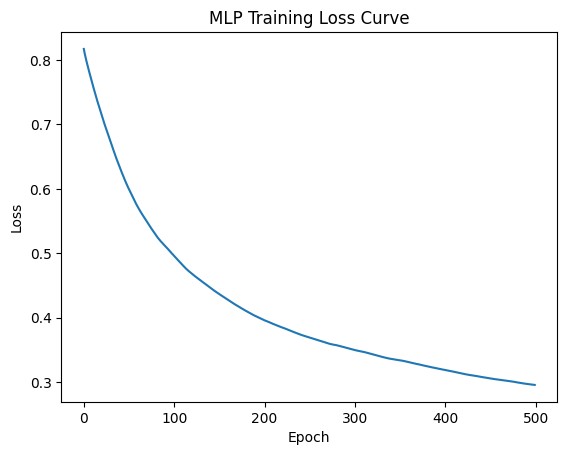

In [19]:
import matplotlib.pyplot as plt

plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [22]:
from sklearn.linear_model import LogisticRegression

# Create logistic regression model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
# Logistic Regression test performance
log_test_acc = accuracy_score(y_test, log_model.predict(X_test))
log_test_auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1])

# MLP test performance
mlp_test_acc = accuracy_score(y_test, mlp.predict(X_test))
mlp_test_auc = roc_auc_score(y_test, mlp.predict_proba(X_test)[:, 1])

print("Logistic Test Accuracy:", log_test_acc)
print("MLP Test Accuracy:", mlp_test_acc)

print("Logistic Test AUC:", log_test_auc)
print("MLP Test AUC:", mlp_test_auc)

Logistic Test Accuracy: 0.8222222222222222
MLP Test Accuracy: 0.7555555555555555
Logistic Test AUC: 0.8064516129032259
MLP Test AUC: 0.8018433179723503


### Why Logistic Regression is a Linear Model
The reason why logistic regression is referred to as a linear model is that it involves the prediction of values by a weighted sum of the input features with a bias term. The model simply takes the initial features and does not transform them using the hidden layers.

Though this final result is changed into a probability through a function, the nature of the relationship between the features, and the prediction is linear based. It implies that this model identifies the classes on one straight decision boundary.

Due to this reason, logistic regression is unable to represent complex or nonlinear relationships among features, which is a limitation when compared to neural networks.

### Training and Behaviour validation.

In the comparison of the logistic regression and the MLP, there are a number of things that should be taken into account:
1.convergence behaviour
2.stability of metrics
3.separation of training and validation performance
### Regression Behaviour Logistics.
Logistic regression generally shows predictable and stable training behaviour as it has quite a low representational capacity. As it can only fit a linear decision boundary, the parameter count is also limited and thereby lowers the chance of overfitting.
In effect, it is usually followed by:
1.comparable training and validation set results.
2.easy convergence in optimisation.
3.low measure changes in evaluation measures.

Nonlinear interactions among features are however not modeled by the model, and therefore its abilities to predict may level off at relatively early stages.

### Representational Capacity vs Overfitting.

A Multi-Layer Perceptron (MLP) is obtained by replacing a linear activation function with nonlinear ReLU activation function in a hidden layer. Nonlinearity is created in the ReLU usage, making the model learn more intricate relations and interactions between the input features. The nonlinear activation functions would make the multi-layers act as a single linear model and would not enhance the ability to learn of the model.

The model can be further increased with the addition of ReLU to reach a higher level of representational power, i.e. it is able to capture more complex patterns in the dataset. When the performance on validation is enhanced and it is similar to training performance, it implies that the model is learning effective patterns that can be applied to new data. Nonetheless, when the level of training performance significantly exceeds the level of validation performance, producing a substantial disparity between them, then this is an indication of overfitting, in which case the model has learned the training data rather than the general patterns.


In [25]:
## TASK 2
from sklearn.metrics import accuracy_score, log_loss

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss

In [29]:
# Define MLP model with tanh activation
model_tanh = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation='tanh',
    max_iter=1,
    warm_start=True,
    random_state=42
)

# Lists to store metrics
train_loss_history = []
validation_loss_history = []
train_accuracy_history = []
validation_accuracy_history = []

# Training loop
for epoch_step in range(epochs):

    # Fit model for one iteration
    model_tanh.fit(X_train, y_train)

    # Generate predictions
    train_outputs = model_tanh.predict(X_train)
    validation_outputs = model_tanh.predict(X_val)

    # Generate predicted probabilities
    train_probs = model_tanh.predict_proba(X_train)
    validation_probs = model_tanh.predict_proba(X_val)

    # Store loss values
    train_loss_history.append(log_loss(y_train, train_probs))
    validation_loss_history.append(log_loss(y_val, validation_probs))

    # Store accuracy values
    train_accuracy_history.append(accuracy_score(y_train, train_outputs))
    validation_accuracy_history.append(accuracy_score(y_val, validation_outputs))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691

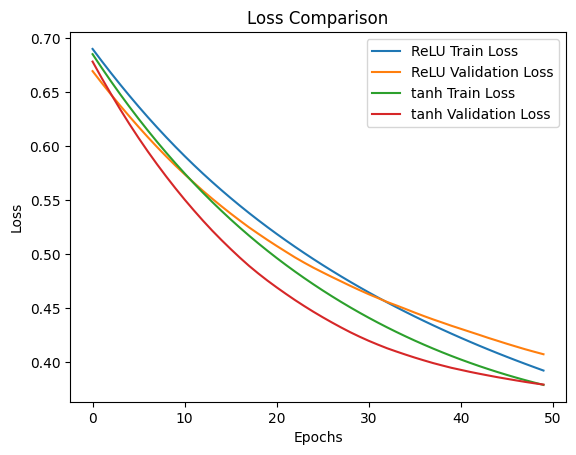

In [34]:
plt.figure()

plt.plot(relu_train_loss, label="ReLU Train Loss")
plt.plot(relu_val_loss, label="ReLU Validation Loss")

plt.plot(train_loss_history, label="tanh Train Loss")
plt.plot(validation_loss_history, label="tanh Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()

plt.show()

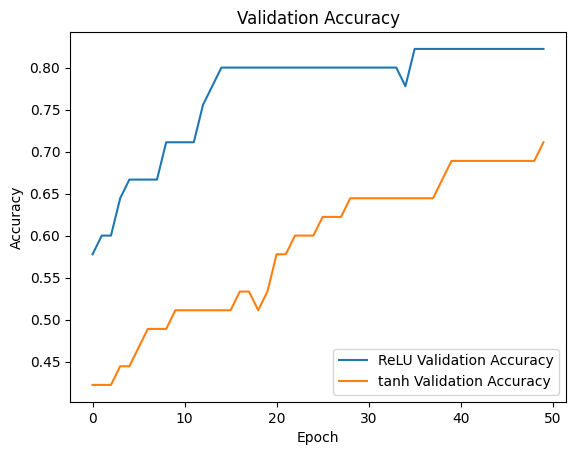

In [43]:
import matplotlib.pyplot as plt

plt.plot(relu_val_acc, label="ReLU Validation Accuracy")
plt.plot(tanh_val_acc, label="tanh Validation Accuracy")

plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

In [50]:
relu_train_loss = relu_model.loss_curve_
tanh_train_loss = tanh_model.loss_curve_

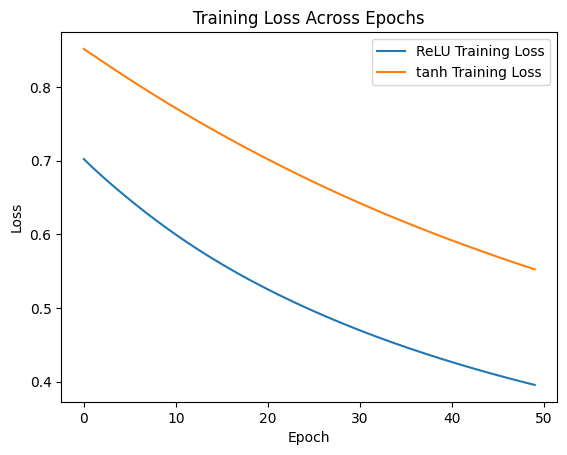

In [51]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(relu_train_loss, label="ReLU Training Loss")
plt.plot(tanh_train_loss, label="tanh Training Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Across Epochs")

plt.legend()

plt.show()

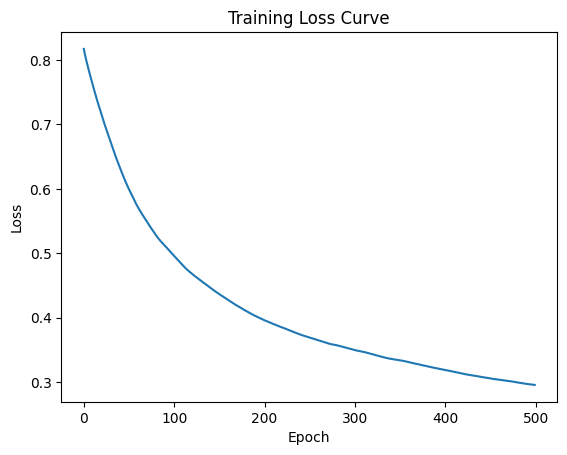

In [53]:
import matplotlib.pyplot as plt

plt.plot(mlp.loss_curve_)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

### COVERGENCE SPEED
The speed of convergence is a measure of how fast a model learns and how fixed it is in a stable minimum loss of the model.

In neural networks, it refers to the required amount of epochs during which the model will be stabilised and not increase significantly.

Better convergence rate Faster convergence learns in fewer epochs.

Slower convergence - model requires more epochs in order to be stable in its performance.

### GRADIENT SATURATION IN TANH
Gradient saturation occurring in tanh occurs in cases where the values of the inputs are extremely large or tiny. In such areas, tanh function values are near -1 or 1, which makes the gradient very small (almost zero).

This causes a very slow pace of weight updating and thus slows the learning process in the course of training.

### Dying ReLU Problem
A ReLU activation function is such that when the input is negative, the output is zero. When negative inputs are fed to a neuron on many occasions, the gradient of the neuron also attains the value of zero on many occasions during backpropagation. Consequently, the weights of the neuron cease to be updated in the process of training. This is called the dying ReLU problem where some neurons are more or less out of commission to the learning process since they are no longer active and do not alter their parameters any more.

### Training Stability
ReLU normally results in more robust and efficient training due to the fact that it permits the positive values of the input by holding the gradients stronger which enables the model to update its weights faster than the learning process. Conversely, the tanh activation function may lead to slower convergence due to the fact that the gradients are often exceedingly small in the event that the inputs are huge in magnitude. This phenomenon is called gradient saturation and may reduce the learning speed and increase the complexity and instability of deeper networks to train.

In [61]:
### TASK 3
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Create a neural network with a small hidden layer
model_small_net = MLPClassifier(
    hidden_layer_sizes=(8,),
    activation="relu",
    max_iter=200,
    random_state=42
)

# Train the model on the training dataset
model_small_net.fit(X_train, y_train)

# Calculate accuracy on the training data
train_accuracy_small = accuracy_score(y_train, model_small_net.predict(X_train))

# Calculate accuracy on the validation data
validation_accuracy_small = accuracy_score(y_val, model_small_net.predict(X_val))

# Display the results
print("Small Network Train Accuracy:", train_accuracy_small)
print("Small Network Validation Accuracy:", validation_accuracy_small)

Small Network Train Accuracy: 0.8229665071770335
Small Network Validation Accuracy: 0.7555555555555555


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [62]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Initialize a neural network with a larger hidden layer
big_network_model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    max_iter=200,
    random_state=42
)

# Train the model using the training dataset
big_network_model.fit(X_train, y_train)

# Compute accuracy on the training data
train_accuracy_large = accuracy_score(y_train, big_network_model.predict(X_train))

# Compute accuracy on the validation data
validation_accuracy_large = accuracy_score(y_val, big_network_model.predict(X_val))

# Print the evaluation results
print("Large Network Train Accuracy:", train_accuracy_large)
print("Large Network Validation Accuracy:", validation_accuracy_large)

Large Network Train Accuracy: 0.9043062200956937
Large Network Validation Accuracy: 0.8


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [63]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Create a neural network with L2 regularisation
l2_model = MLPClassifier(
    hidden_layer_sizes=(128,),
    activation="relu",
    alpha=0.001,   # L2 weight decay
    max_iter=200,
    random_state=42
)

# Train the model using the training dataset
l2_model.fit(X_train, y_train)

# Calculate accuracy on the training dataset
train_accuracy_l2 = accuracy_score(y_train, l2_model.predict(X_train))

# Calculate accuracy on the validation dataset
validation_accuracy_l2 = accuracy_score(y_val, l2_model.predict(X_val))

# Display the results
print("Regularised Train Accuracy:", train_accuracy_l2)
print("Regularised Validation Accuracy:", validation_accuracy_l2)

Regularised Train Accuracy: 0.9043062200956937
Regularised Validation Accuracy: 0.8


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


### FINAL ANALYSIS
Increasing network size increases the model capacity which guarantees the network to represent complex functions. With small datasets, such as this one consisting of 299 samples, large networks can easily memorise the training data.

This typically results in overfitting, a phenomenon where training accuracy becomes very high, while validation accuracy either stops improving or decreases altogether.

Regularisation techniques such as dropout help reduce overfitting by ”randomly switching of neurons” during training. This forces the model to learn a more generic representation and not depend on certain neurons.

In [66]:
## TASK 4
from sklearn.metrics import accuracy_score, roc_auc_score

models = {
    "Logistic Regression": log_reg,
    "ReLU MLP": relu_model,
    "tanh MLP": tanh_model,
    "Small Network": model_small_net,
    "Regularized Large Network": l2_model
}

for model_name, trained_model in models.items():

    # Predictions
    test_predictions = trained_model.predict(X_test)

    # Probability scores for ROC-AUC
    test_probabilities = trained_model.predict_proba(X_test)[:, 1]

    # Metrics
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_auc = roc_auc_score(y_test, test_probabilities)

    print(model_name)
    print("Test Accuracy:", test_accuracy)
    print("Test ROC-AUC:", test_auc)
    print()

Logistic Regression
Test Accuracy: 0.8222222222222222
Test ROC-AUC: 0.8064516129032259

ReLU MLP
Test Accuracy: 0.7555555555555555
Test ROC-AUC: 0.815668202764977

tanh MLP
Test Accuracy: 0.6888888888888889
Test ROC-AUC: 0.6658986175115207

Small Network
Test Accuracy: 0.6888888888888889
Test ROC-AUC: 0.7119815668202765

Regularized Large Network
Test Accuracy: 0.7555555555555555
Test ROC-AUC: 0.7972350230414746



### Role of Training Data

Training data is necessary for fitting model parameters. The model learns patterns and relationships between features and the target variable in this stage.

### Role of Validation Data

The validation data set is used in tuning the hyperparameters and also makes decisions on the model architecture. The data is collected during development to give an estimate of how best the model generalises on previously unseen examples.

### Why Test Data Must Not Guide Decisions

The test set is not supposed to be encountered during the mindset stage. The test set becomes de facto training data if model design decisions are based on test results, causing an optimistic bias in performance estimates.

### Why Small Differences Should Not Be Overinterpreted

As the dataset is small, performance metrics are liable to change depending on the random initialization during training and data splitting. The numerical values that differentiate one model from another should be taken with caution and not likely reflect improvements of some sort or another (ibid).